In [4]:
import numpy as np 
import torch
import xarray as xr

import sys
sys.path.append('../')
import dpa_ensemble as de
import utils as ut
import evaluation
from engression.loss_func import energy_loss, energy_loss_two_sample
import matplotlib.pyplot as plt
import json

In [5]:
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)

ds = xr.open_dataset(settings['dataset_trefht'])
print("Dataset:", settings['dataset_trefht'])

# set train/test split
ds_train = ds.isel(time=slice(0, 4769 * 10)) #4769 * 80
ds_test = ds.isel(time=slice(4769 * 10, 476900)) #4769 * 80

print(ds_train.TREFHT.shape)
print(ds_test.TREFHT.shape)


# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

print(x_tr.shape)
print(x_te.shape)

# load Z500
#ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
#ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
#print("z500 shape", ds_z500.shape)
#z500 = torch.from_numpy(ds_z500)
#print("z500 shape", z500.shape)


#z500_train = z500[:int(128000),:]
#z500_test = z500[int(-64000):,:]

# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)

Dataset: /work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/v4_starting08122025/europe_10percent_masked_stacked_TREFHT_JJA_v3.nc
(32, 32, 47690)
(32, 32, 429210)
torch.Size([47690, 1024])
torch.Size([429210, 1024])
torch.Size([47690, 1024])
torch.Size([429210, 1024])


In [24]:
import torch

def pca_reconstruct_rmse(X, n_components):
    """
    X: (n_samples, n_features) torch tensor
    n_components: number of principal components to keep
    """

    # 1. Center data
    X_mean = X.mean(dim=0)
    X_centered = X - X_mean

    # 2. PCA via SVD
    U, S, Vt = torch.linalg.svd(X_centered, full_matrices=False)

    # 3. Keep top PCs
    Vt_k = Vt[:n_components]                # (k, n_features)

    # 4. Projection
    X_proj = X_centered @ Vt_k.T           # (n_samples, k)
    print("projection shape:", X_proj.shape)
    
    # 5. Reconstruction
    X_rec = X_proj @ Vt_k + X_mean         # (n_samples, n_features)
    print("Reconstruction shape:", X_rec.shape)
    
    # 6. RMSE per sample
    mse = torch.mean((X - X_rec)**2, dim=1)  # (n_samples,)
    rmse = torch.sqrt(mse)
    print("Reconstruction shape:", X_rec.shape)
    return X_rec, rmse

def pca_variance_explained(X):
    # X: (n_samples, n_features)
    Xc = X - X.mean(dim=0, keepdim=True)

    # SVD: Xc = U diag(S) Vt
    U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)

    # eigenvalues of covariance = S^2 / (n_samples - 1)
    n = Xc.shape[0]
    eigvals = (S**2) / (n - 1)

    # explained variance ratio per PC + cumulative
    evr = eigvals / eigvals.sum()
    cev = torch.cumsum(evr, dim=0)
    return evr, cev


In [21]:
x_tr_reduced.shape

torch.Size([47690, 648])

projection shape: torch.Size([47690, 648])
Reconstruction shape: torch.Size([47690, 648])
Reconstruction shape: torch.Size([47690, 648])
X_rec.shape torch.Size([47690, 648])
torch.Size([47690])
RMSE_res shape torch.Size([10, 4769])
RMSE_mean shape torch.Size([4769])


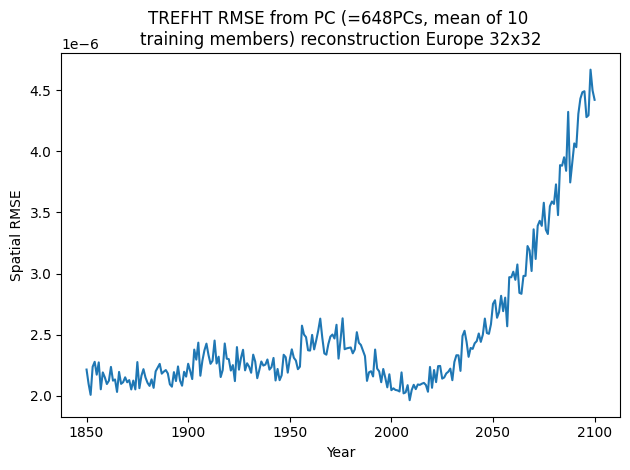

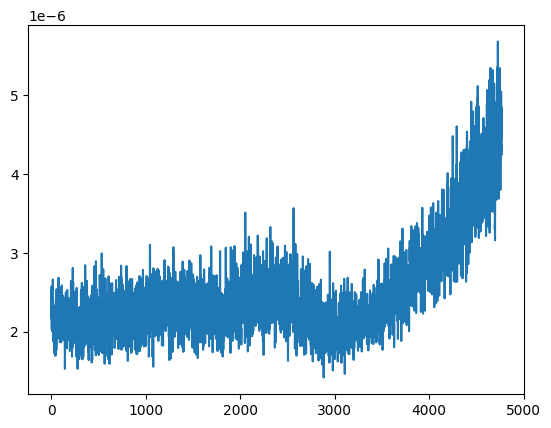

In [32]:
# all time
X = x_tr_reduced
no_pcs = 648
X_rec, rmse = pca_reconstruct_rmse(X, no_pcs)

print("X_rec.shape", X_rec.shape)
print(rmse.shape)



### RMSE ###

# reshape RMSE to calculate mean across 10 training members
rmse_res = rmse.reshape((10,4769))
print("RMSE_res shape",rmse_res.shape)
rmse_mean = rmse_res.mean(dim=0)
ts = rmse_mean  # shape (4769,) torch tensor (or any 1D tensor)
print("RMSE_mean shape",rmse_mean.shape)

# calculate yearly mean values
block = 19
n_blocks = ts.numel() // block 
ts19 = ts[:n_blocks * block].reshape(n_blocks, block).mean(dim=1)

# plot
plt.plot(range(1850,2101), ts19)
plt.xlabel("Year")
plt.ylabel("Spatial RMSE")
plt.title(f"TREFHT RMSE from PC (={no_pcs}PCs, mean of 10 \ntraining members) reconstruction Europe 32x32")
plt.tight_layout()
plt.savefig("figures/RMSE_from_PCA.pdf")
plt.show()

plt.plot(rmse_mean)
#plt.title()

In [ ]:
evr, cev = pca_variance_explained(X)

# Variance explained per PC
plt.figure()
plt.plot(evr.detach().cpu().numpy())
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Variance explained per PC")
plt.tight_layout()
plt.xlim(0,10)
plt.show()

# Optional: cumulative variance explained
plt.figure()
plt.plot(cev.detach().cpu().numpy())
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative variance explained")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

torch.Size([10, 1900, 648])


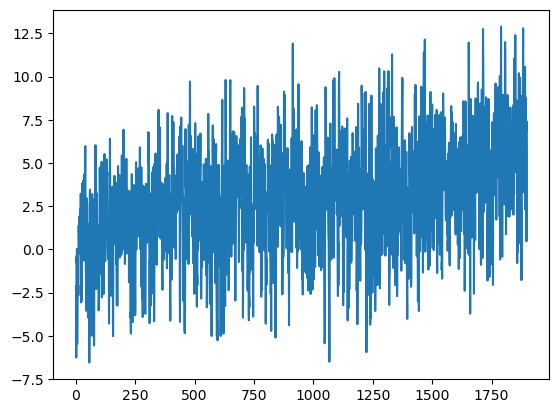

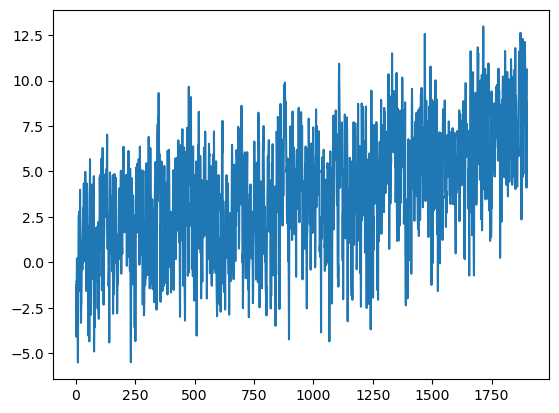

In [55]:
# only 2000 - 2100
# is this correct?
X = x_tr_reduced.reshape((10, 4769,648))[:,-1900:4769,:]
print(X.shape)
plt.plot(X[0,:,1])
plt.show()
X_re = X.reshape((19000,648))
plt.plot(X_re[:1900,100])

tensor([0.2298, 0.2324, 0.2082,  ..., 0.2771, 0.2431, 0.2132])
torch.Size([10, 1900])


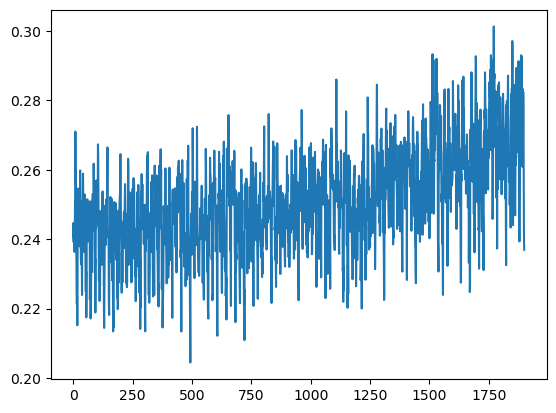

In [57]:
X_rec, rmse = pca_reconstruct_rmse(X_re, 100)

print(rmse)   # RMSE for each sample
rmse.shape

rmse_res = rmse.reshape((10,1900))
print(rmse_res.shape)
rmse_mean = rmse_res.mean(dim=0)
rmse_mean.shape
plt.plot(rmse_mean)